# Chapter 9 notebook — TinyML keyword spotting (concept walk-through)

Walks through `docs/12_tinyml_microcontrollers.md` interactively, using the synthetic 3-class keyword dataset from `project_05_tinyml_keyword_spotting`.

Before running: from the project directory run `python generate_synthetic.py && python train_kws.py`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
sys.path.insert(0, str(Path('../projects/project_05_tinyml_keyword_spotting').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch

from train_kws import compute_mfcc, TinyDSCNN
from footprint import estimate_activation_peak

DATA = Path('../datasets/kws_synthetic.npz')
CKPT = Path('../projects/project_05_tinyml_keyword_spotting/results/kws_model.pt')
assert DATA.exists() and CKPT.exists(), 'run generate_synthetic.py + train_kws.py first'

blob = np.load(DATA, allow_pickle=True)
X = blob['X']
y = blob['y']
names = list(blob['names'])
print('audio:', X.shape, '| classes:', names)

audio: (600, 16000) | classes: [np.str_('up'), np.str_('down'), np.str_('stop')]


## 1. The raw waveforms

Three distinguishable spectral patterns — chirps and a two-tone burst.

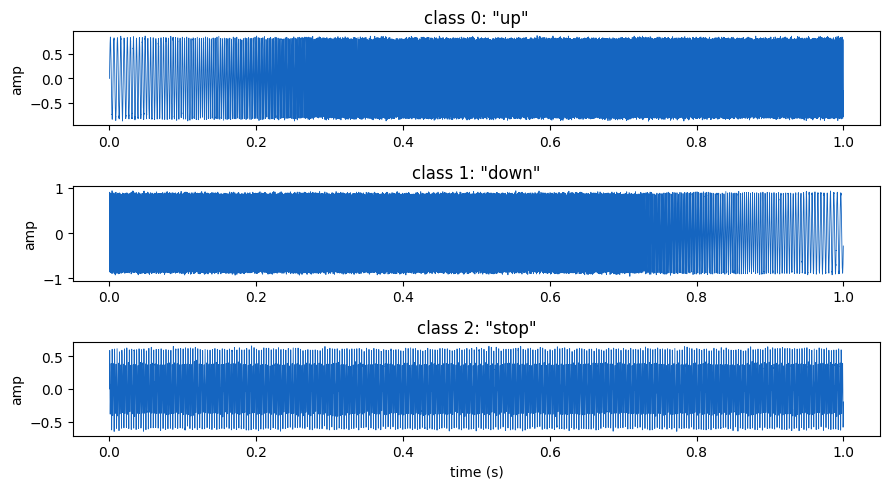

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(9, 5))
rate = 16000
for i, label in enumerate(np.unique(y)):
    sample = X[y == label][0]
    t = np.arange(len(sample)) / rate
    axes[i].plot(t, sample, linewidth=0.6, color='#1565C0')
    axes[i].set_title(f'class {label}: \"{names[label]}\"')
    axes[i].set_ylabel('amp')
axes[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

## 2. MFCC features

MFCC compresses an audio window down to a small set of coefficients that capture spectral envelope. The KWS model runs on these features, not on raw audio.

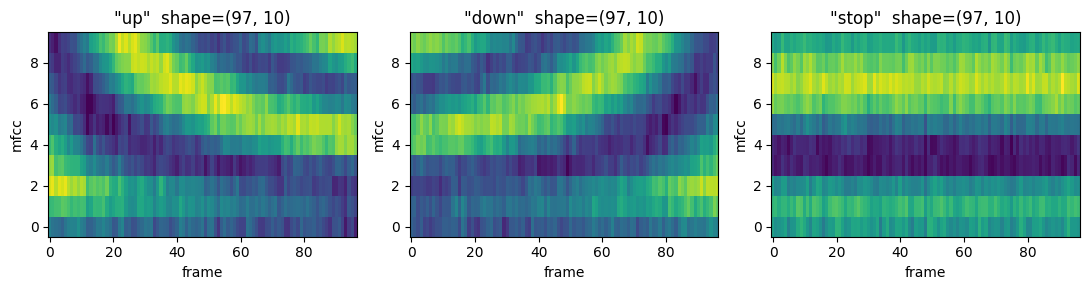

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for i, label in enumerate(np.unique(y)):
    mfcc = compute_mfcc(X[y == label][0], rate=16000, win_ms=30, hop_ms=10, n_mfcc=10)
    im = axes[i].imshow(mfcc.T, aspect='auto', origin='lower', cmap='viridis')
    axes[i].set_title(f'\"{names[label]}\"  shape={mfcc.shape}')
    axes[i].set_xlabel('frame')
    axes[i].set_ylabel('mfcc')
plt.tight_layout()
plt.show()

## 3. Load the trained model + evaluate

In [4]:
ckpt = torch.load(CKPT, map_location='cpu', weights_only=False)
cfg = ckpt['config']
model = TinyDSCNN(n_classes=cfg['n_classes'], n_mfcc=cfg['n_mfcc'])
model.load_state_dict(ckpt['state_dict'])
model.eval()
n_params = ckpt['n_params']
print(f'params: {n_params}  (~{n_params/1024:.1f} KB INT8)')

# Compute MFCC for every audio sample (fast on this tiny dataset)
all_mfcc = np.stack([
    compute_mfcc(x, 16000, cfg['window_ms'], cfg['hop_ms'], cfg['n_mfcc'])
    for x in X
], axis=0)
with torch.no_grad():
    logits = model(torch.from_numpy(all_mfcc))
    preds = logits.argmax(dim=1).numpy()
acc = float((preds == y).mean())
print(f'accuracy on the full synthetic set: {acc:.3f}')

params: 2727  (~2.7 KB INT8)


accuracy on the full synthetic set: 1.000


## 4. Footprint and which MCU it would fit

In [5]:
in_shape = (1, all_mfcc.shape[1], cfg['n_mfcc'])
peak_bytes = estimate_activation_peak(model, in_shape)
peak_kb_int8 = peak_bytes / 1024 / 4
flash_int8_kb = n_params / 1024
print(f'flash (INT8 weights):   {flash_int8_kb:6.1f} KB')
print(f'RAM activation (INT8):  {peak_kb_int8:6.1f} KB')

boards = [('Arduino Nano 33 BLE Sense', 256, 1024),
          ('Raspberry Pi Pico', 264, 2048),
          ('ESP32-S3 (no PSRAM)', 512, 8192),
          ('STM32 H7', 1024, 2048)]
print()
print(f'{"board":<32s} {"RAM KB":>8s} {"Flash KB":>10s} {"fits INT8?":>12s}')
for name, ram_kb, flash_kb in boards:
    ok = 'YES' if (peak_kb_int8 <= ram_kb * 0.5 and flash_int8_kb <= flash_kb * 0.5) else 'TIGHT/NO'
    print(f'{name:<32s} {ram_kb:>8d} {flash_kb:>10d} {ok:>12s}')

flash (INT8 weights):      2.7 KB
RAM activation (INT8):     3.0 KB

board                              RAM KB   Flash KB   fits INT8?
Arduino Nano 33 BLE Sense             256       1024          YES
Raspberry Pi Pico                     264       2048          YES
ESP32-S3 (no PSRAM)                   512       8192          YES
STM32 H7                             1024       2048          YES


## Take-aways

1. TinyML inference is **MFCC + tiny CNN**, not raw audio + huge model.
2. Memory math is half the design — both weights and activations have to fit.
3. The same `.tflite` file produced by quantizing this model is what would flash to a real Cortex-M board via TensorFlow Lite Micro.
4. For a *real* keyword spotter, swap the synthetic dataset for Google Speech Commands, train longer, and evaluate on the real hardware you target.